In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

print("Libraries loaded")

Libraries loaded


In [3]:
df = pd.read_csv("../data/2019-Nov.csv")

df.shape

(67501979, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67501979 entries, 0 to 67501978
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     object 
 1   event_type     object 
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  object 
 5   brand          object 
 6   price          float64
 7   user_id        int64  
 8   user_session   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 4.5+ GB


In [5]:
df['event_time'] = pd.to_datetime(df['event_time'])
df['date'] = df['event_time'].dt.date

In [6]:
df['event_type'].value_counts()

event_type
view        63556110
cart         3028930
purchase      916939
Name: count, dtype: int64

In [7]:
funnel = df.groupby('event_type')['user_id'].nunique()
funnel = funnel.reindex(['view', 'cart', 'purchase'])
funnel

event_type
view        3695598
cart         826323
purchase     441638
Name: user_id, dtype: int64

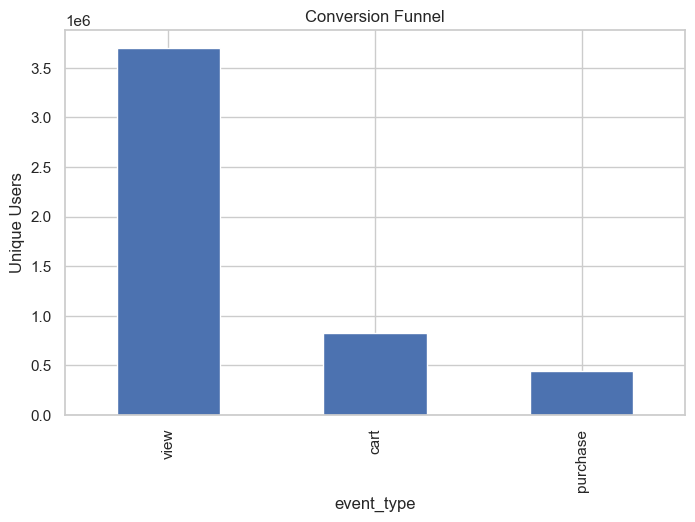

In [93]:
import matplotlib.pyplot as plt
funnel.plot(kind='bar', figsize=(8,5))
plt.title('Conversion Funnel')
plt.ylabel('Unique Users')
plt.savefig('../screenshots/conversion_funnel.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
view_users = set(df[df['event_type'] == 'view']['user_id'])
cart_users = set(df[df['event_type'] == 'cart']['user_id'])
purchase_users = set(df[df['event_type'] == 'purchase']['user_id'])

view_to_cart_users = view_users & cart_users
cart_to_purchase_users = cart_users & purchase_users

In [12]:
view_to_cart = len(view_to_cart_users) / len(view_users)
cart_to_purchase = len(cart_to_purchase_users) / len(cart_users)

print('Conversion view to cart:', round(view_to_cart * 100, 2), '%')
print('Conversion cart to purchase:', round(cart_to_purchase * 100, 2), '%')

Conversion view to cart: 22.35 %
Conversion cart to purchase: 48.41 %


In [13]:
purchase_without_cart = purchase_users - cart_users

print('Purchase without cart:', len(purchase_without_cart))

Purchase without cart: 41591


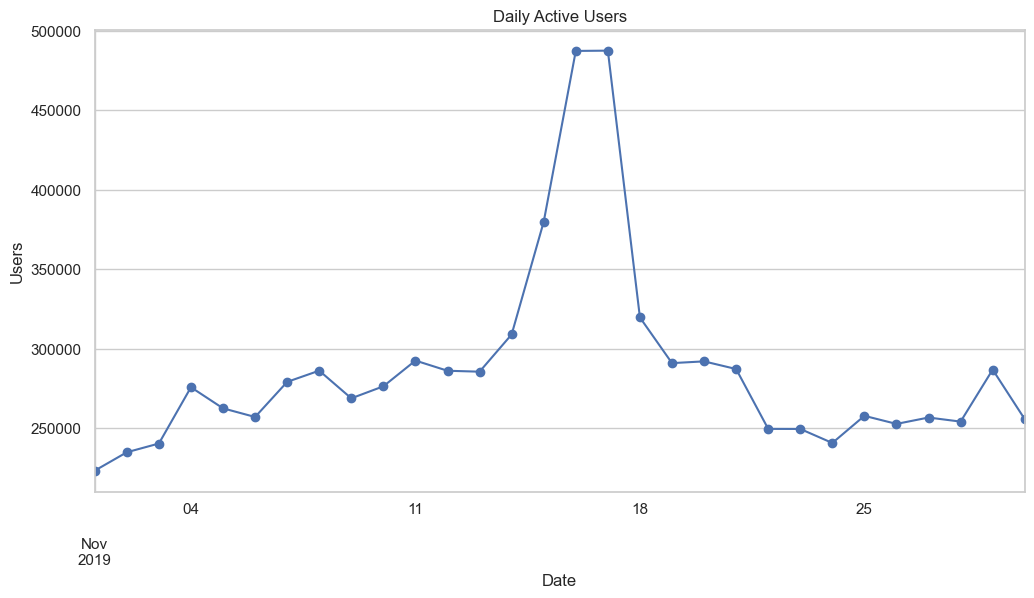

In [94]:
dau = df.groupby('date')['user_id'].nunique()

plt.figure(figsize = (12,6))
dau.plot(marker = 'o')

plt.title('Daily Active Users')
plt.ylabel('Users')
plt.xlabel('Date')

plt.savefig('../screenshots/DAU.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
first_visit = df.groupby('user_id')['date'].min()

In [16]:
df = df.join(first_visit, on='user_id', rsuffix='_first')

In [21]:
df['date'] = pd.to_datetime(df['date'])
df['date_first'] = pd.to_datetime(df['date_first'])

In [22]:
df['days_since_first'] = (df['date'] - df['date_first']).dt.days

In [31]:
ret_df = df[['user_id', 'date']].drop_duplicates().copy()
ret_df.head()

,user_id,date
0,520088904,2019-11-01
1,530496790,2019-11-01
2,561587266,2019-11-01
3,518085591,2019-11-01
4,558856683,2019-11-01


In [34]:
ret_df['user_id'] = ret_df['user_id'].astype('int64')

In [36]:
first_visit = ret_df.groupby('user_id')['date'].min()

In [37]:
ret_df = ret_df.join(first_visit, on='user_id', rsuffix='_first')
ret_df.head()

,user_id,date,date_first
0,520088904,2019-11-01,2019-11-01
1,530496790,2019-11-01,2019-11-01
2,561587266,2019-11-01,2019-11-01
3,518085591,2019-11-01,2019-11-01
4,558856683,2019-11-01,2019-11-01


In [38]:
ret_df['date'] = pd.to_datetime(ret_df['date'])
ret_df['date_first'] = pd.to_datetime(ret_df['date_first'])

ret_df['days_since_first'] = (ret_df['date'] - ret_df['date_first']).dt.days

In [41]:
retention = ret_df.groupby(['date_first', 'days_since_first'])['user_id'].nunique()

In [43]:
retention.head(10)

date_first  days_since_first
2019-11-01  0                   223108
            1                    41734
            2                    34691
            3                    36635
            4                    32916
            5                    31128
            6                    31610
            7                    30147
            8                    27757
            9                    27727
Name: user_id, dtype: int64

In [44]:
retention = retention.unstack()

In [46]:
retention.head()

days_since_first,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
date_first,,,,,,,,,,,,,,,,,,,,,
2019-11-01,223108.0,41734.0,34691.0,36635.0,32916.0,31128.0,31610.0,30147.0,27757.0,27727.0,...,20257.0,19441.0,18603.0,18297.0,18496.0,19876.0,20144.0,19758.0,21959.0,19611.0
2019-11-02,192951.0,29927.0,25884.0,22678.0,21295.0,21538.0,20691.0,19980.0,19757.0,19555.0,...,13627.0,13433.0,13288.0,12797.0,13909.0,14162.0,13654.0,15329.0,14268.0,NaN
2019-11-03,175569.0,25784.0,20111.0,18339.0,18278.0,17445.0,16771.0,16911.0,16447.0,16149.0,...,11086.0,11091.0,10707.0,11639.0,11802.0,11411.0,12658.0,11810.0,NaN,NaN
2019-11-04,187309.0,25730.0,20835.0,19801.0,18230.0,16304.0,16159.0,17596.0,17123.0,16370.0,...,10646.0,10954.0,11664.0,12045.0,11646.0,13129.0,11364.0,NaN,NaN,NaN
2019-11-05,160903.0,20099.0,16712.0,14635.0,12999.0,12791.0,13619.0,13194.0,12733.0,14861.0,...,8723.0,9426.0,9298.0,9065.0,10095.0,8755.0,NaN,NaN,NaN,NaN


In [47]:
retention = retention.div(retention[0], axis = 0)

In [48]:
retention.head()

days_since_first,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
date_first,,,,,,,,,,,,,,,,,,,,,
2019-11-01,1.0,0.187057,0.155490,0.164203,0.147534,0.139520,0.141680,0.135123,0.124411,0.124276,...,0.090795,0.087137,0.083381,0.082010,0.082902,0.089087,0.090288,0.088558,0.098423,0.087899
2019-11-02,1.0,0.155102,0.134148,0.117532,0.110365,0.111624,0.107234,0.103550,0.102394,0.101347,...,0.070624,0.069619,0.068867,0.066323,0.072086,0.073397,0.070764,0.079445,0.073946,NaN
2019-11-03,1.0,0.146860,0.114548,0.104455,0.104107,0.099363,0.095524,0.096321,0.093678,0.091981,...,0.063143,0.063172,0.060985,0.066293,0.067221,0.064994,0.072097,0.067267,NaN,NaN
2019-11-04,1.0,0.137367,0.111233,0.105713,0.097326,0.087043,0.086269,0.093941,0.091416,0.087396,...,0.056837,0.058481,0.062271,0.064306,0.062175,0.070093,0.060670,NaN,NaN,NaN
2019-11-05,1.0,0.124914,0.103864,0.090955,0.080788,0.079495,0.084641,0.082000,0.079135,0.092360,...,0.054213,0.058582,0.057786,0.056338,0.062740,0.054412,NaN,NaN,NaN,NaN


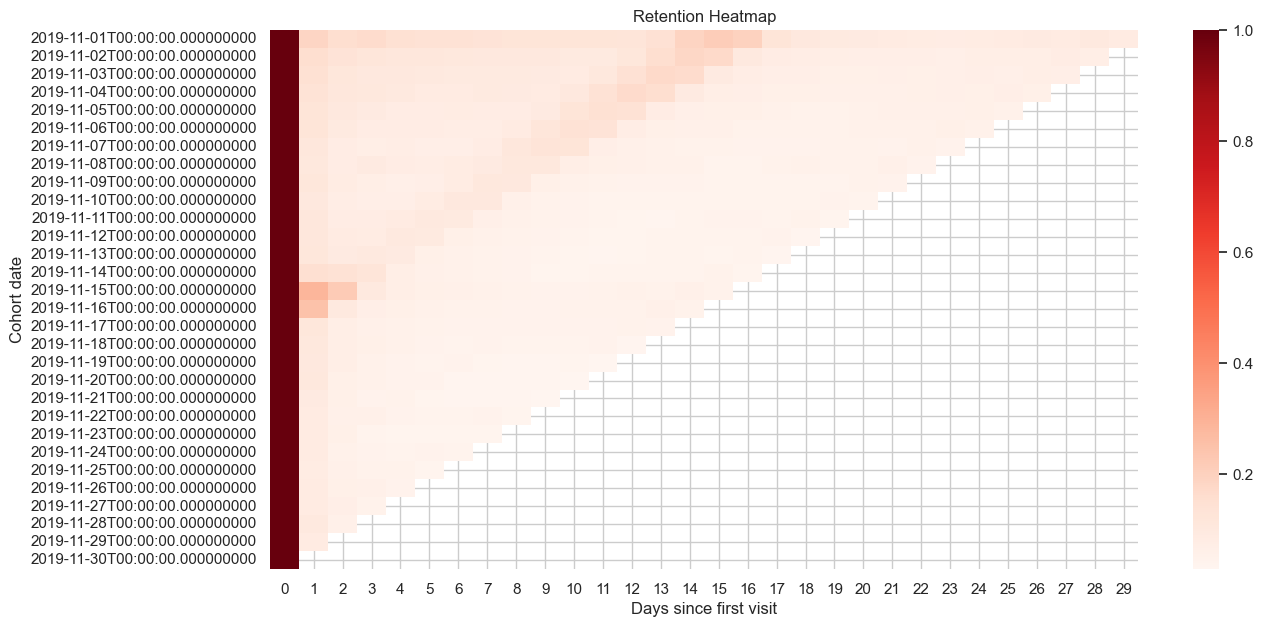

In [92]:
plt.figure(figsize = (14,7))
sns.heatmap(retention.iloc[:, :30], annot=False, cmap='Reds')
plt.title('Retention Heatmap')
plt.xlabel('Days since first visit')
plt.ylabel('Cohort date')

plt.savefig('../screenshots/retention_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [68]:
day_1_retention = retention[1].mean()
day_7_retention = retention[7].mean()
day_14_retention = retention[14].mean()
day_29_retention = retention[29].mean()

print('Average Day 1 retention:', round(day_1_retention * 100, 2), '%')
print('Average Day 7 retention:', round(day_7_retention * 100, 2), '%')
print('Average Day 14 retention:', round(day_14_retention * 100, 2), '%')
print('Average Day 29 retention:', round(day_29_retention * 100, 2), '%')

Average Day 1 retention: 12.31 %
Average Day 7 retention: 6.81 %
Average Day 14 retention: 7.62 %
Average Day 29 retention: 8.79 %


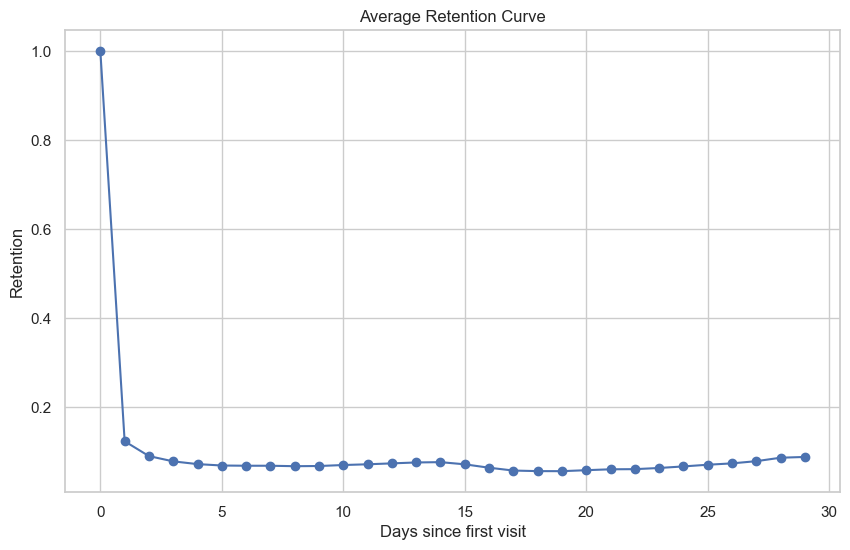

In [95]:
avg_retention = retention.mean()
plt.figure(figsize = (10,6))
avg_retention[:30].plot(marker='o')
plt.title('Average Retention Curve')
plt.xlabel('Days since first visit')
plt.ylabel('Retention')

plt.savefig('../screenshots/avg_retention_curve', dpi=300, bbox_inches='tight')
plt.show()

In [78]:
purchases = df[df['event_type'] == 'purchase']

In [79]:
purchases.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,date,date_first,days_since_first
107,2019-11-01 00:00:41+00:00,purchase,13200605,2053013557192163841,furniture.bedroom.bed,NaN,566.30,559368633,d6034fa2-41fb-4ac0-9051-55ea9fc9147a,2019-11-01,2019-11-01,0
168,2019-11-01 00:01:04+00:00,purchase,1005161,2053013555631882655,electronics.smartphone,xiaomi,211.92,513351129,e6b7ce9b-1938-4e20-976c-8b4163aea11d,2019-11-01,2019-11-01,0
707,2019-11-01 00:04:51+00:00,purchase,1004856,2053013555631882655,electronics.smartphone,samsung,128.42,562958505,0f039697-fedc-40fa-8830-39c1a024351d,2019-11-01,2019-11-01,0
811,2019-11-01 00:05:34+00:00,purchase,26401669,2053013563651392361,NaN,lucente,109.66,541854711,c41c44d5-ef9b-41b9-9cd6-8d96dda6e927,2019-11-01,2019-11-01,0
939,2019-11-01 00:06:33+00:00,purchase,1801881,2053013554415534427,electronics.video.tv,samsung,488.80,557746614,4d76d6d3-fff5-4880-8327-e9e57b618e0e,2019-11-01,2019-11-01,0


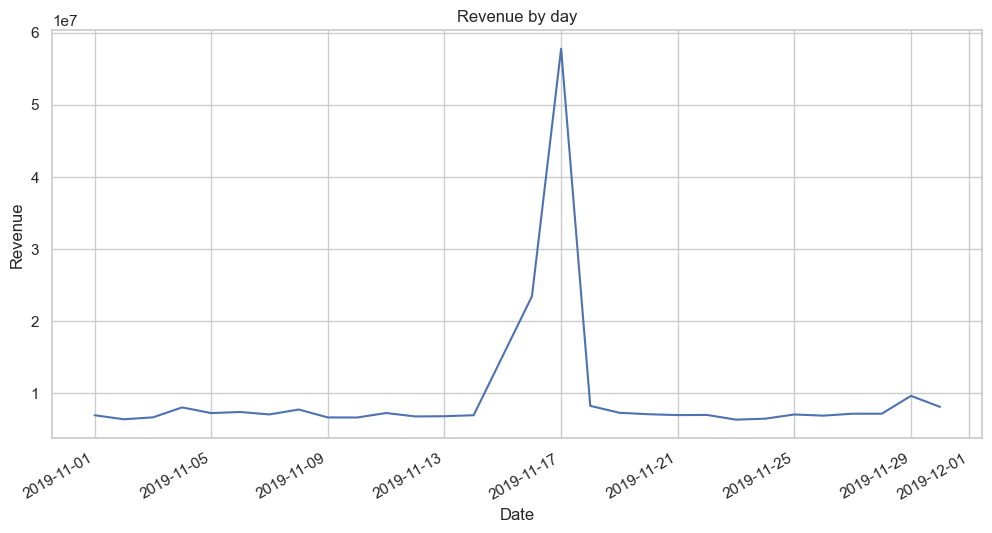

In [96]:
revenue_by_date = purchases.groupby('date')['price'].sum()
plt.figure(figsize = (12,6))
revenue_by_date.plot()
plt.title('Revenue by day')
plt.xlabel('Date')
plt.ylabel('Revenue')

plt.savefig('../screenshots/revenue_by_date.png', dpi=300, bbox_inches='tight')
plt.show()

In [83]:
total_revenue = purchases['price'].sum()
total_users = df['user_id'].nunique()

arpu = total_revenue / total_users

print('Total revenue:', round(total_revenue, 2))
print('Total users:', round(total_users, 2))
print('ARPU:', round(arpu, 2))

Total revenue: 275194890.5
Total users: 3696117
ARPU: 74.46


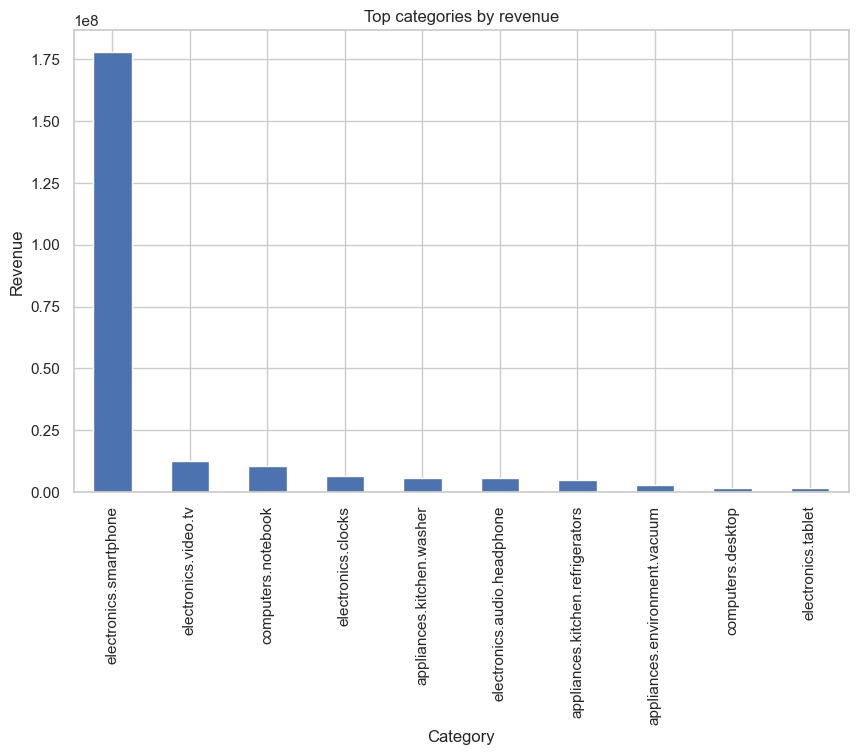

In [97]:
top_categories = purchases.groupby('category_code')['price'].sum().sort_values(ascending = False).head(10)

plt.figure(figsize = (10,6))
top_categories.plot(kind='bar')
plt.title('Top categories by revenue')
plt.xlabel('Category')
plt.ylabel('Revenue')

plt.savefig('../screenshots/top_categories.png', dpi=300, bbox_inches='tight')
plt.show()

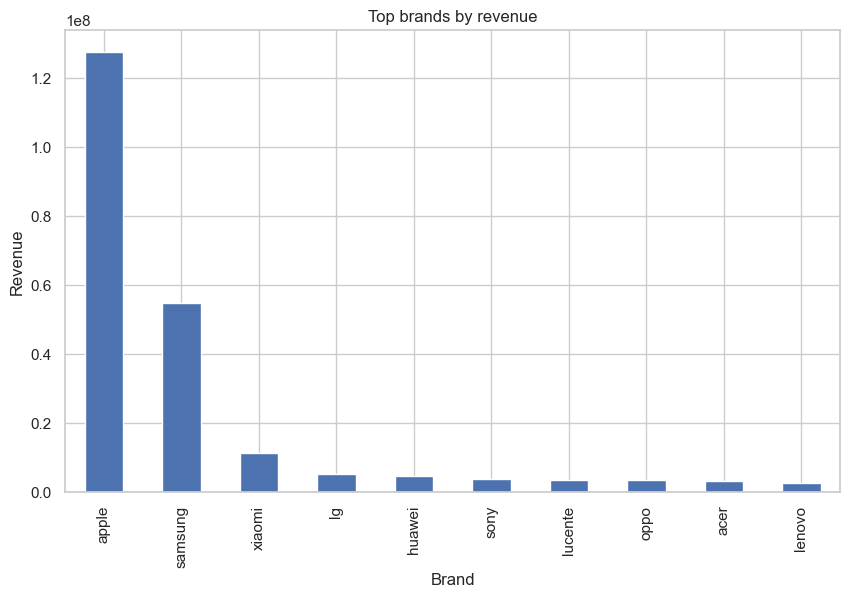

In [98]:
top_brands = purchases.groupby('brand')['price'].sum().sort_values(ascending = False).head(10)

plt.figure(figsize = (10,6))
top_brands.plot(kind='bar')
plt.title('Top brands by revenue')
plt.xlabel('Brand')
plt.ylabel('Revenue')

plt.savefig('../screenshots/top_brands.png', dpi=300, bbox_inches='tight')
plt.show()